# Module C Milestone 2: Data Science Capstone
## Week 10 — K-Means Clustering (v2: Scale → PCA → Cluster)

**Methods covered:**
1. **K-Means** — partitions n points into k clusters minimising WCSS = Σ Σ ‖x − μⱼ‖²
2. **WCSS Elbow Method** — inertia vs k; the "elbow" suggests a natural cluster count
3. **Silhouette Score** — s(i) = (b(i) − a(i)) / max(a(i), b(i)); range [−1, +1], higher = better
4. **PCA pre-processing** — `PCA(n_components=0.85)` applied *before* K-Means to reduce noise
   dimensions while retaining 85% of variance; first 2 PCs reused for scatter plots
5. **Distance metric: Euclidean (L2)** — K-Means uses Euclidean distance exclusively.
   The centroid (arithmetic mean) is the unique point that minimises the sum of *squared* Euclidean
   distances within a cluster. This identity — mean minimises squared L2 — is what makes the
   "assign → recompute centroid" iteration valid. Other metrics break it: the point minimising
   summed Manhattan (L1) distances is the component-wise median, not the mean, so the standard
   update rule no longer converges to a local optimum of the chosen objective.
   `sklearn.cluster.KMeans` therefore has no `metric` parameter — Euclidean is hardcoded by design.

**Pipeline (per dataset):**
```
Raw data → Encode → StandardScaler → PCA(85%) → K-Means sweep (k=2..29)
                                          ↓
                              PC1/PC2 used for 2D scatter
```

**Design notes vs v1:**
- Sample sizes enlarged: Fraud 30K (was 10K) · Credit 10K · Loan 15K
- Dummy variables retained — transaction `category` is top-1 fraud predictor (Wk9 GBM);
  dropping it would destroy cluster signal. Noted as limitation below.
- PCA before K-Means: reduces curse of dimensionality; 2D scatter now shows structure
  within the same feature space used for clustering (not a separate 2-component projection)

**Note:** Clustering is unsupervised — true labels used ONLY for post-hoc overlay.
**Primary metric (supervised):** AUC-ROC | **Clustering:** Silhouette Score + WCSS

In [1]:
# ===========================================================================
# ALL IMPORTS — every library used anywhere in this notebook
# ===========================================================================
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.cluster      import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics      import silhouette_score

warnings.filterwarnings('ignore')

In [2]:
# ===========================================================================
# CONFIGURATION
# ===========================================================================
DATA_DIR              = r'E:\BU\CDSDX 699 O2\data'
CARDINALITY_THRESHOLD = 50

PRIOR_AUC = {
    'fraud':  {'Wk1':0.9820,'Wk2':0.9817,'Wk3':0.9378,
               'Wk4':0.9651,'Wk5':0.9457,'Wk6_DT':0.9757,'Wk6_RF':0.9802,
               'Wk8_KNN':0.8791,'Wk9_GBM':0.9825},
    'credit': {'Wk1':0.9990,'Wk2':0.9993,'Wk3':0.9874,
               'Wk4':0.9998,'Wk5':0.9999,'Wk6_DT':0.9784,'Wk6_RF':0.9995,
               'Wk8_KNN':0.9056,'Wk9_GBM':0.9999},
    'loan':   {'Wk1':0.6816,'Wk2':0.6832,'Wk3':0.6810,
               'Wk4':0.6864,'Wk5':0.6039,'Wk6_DT':0.6661,'Wk6_RF':0.6943,
               'Wk8_KNN':0.6254,'Wk9_GBM':0.7030},
}

TARGET_F   = 'is_fraud'
TARGET_C   = 'Status'
TARGET_L   = 'Default'

CAT_COLS_F = ['category', 'gender']
CAT_COLS_C = ['Applicant_Gender', 'Income_Type', 'Education_Type',
              'Family_Status', 'Housing_Type', 'Job_Title']
CAT_COLS_L = ['GGGrade', 'Home_Status', 'Duration', 'Reason',
              'Claim_Type', 'File_Status', 'Validation', 'Experience']

DROP_IDS_C = ['Applicant_ID']
DROP_IDS_L = ['ID', 'Asst_Reg']

# v2: enlarged samples for better post-hoc profiling
SAMPLE_F   = 30_000   # 0.58% fraud → ~174 fraud rows (was 58 at 10K)
SAMPLE_C   = 10_000   # full dataset ~25K; 10K subsample
SAMPLE_L   = 15_000   # 18.9% default → ~2,835 default rows (was ~1,511 at 8K)

K_RANGE      = range(2, 30)   # k = 2..29
N_INIT       = 10
RANDOM_STATE = 42
PCA_VAR      = 0.85           # retain 85% of variance in PCA pre-processing

WK_MODEL = {
    'Wk1':'Poly-LR','Wk2':'Lasso/Ridge','Wk3':'PCR/PLSR',
    'Wk4':'LogReg','Wk5':'SVM','Wk6_DT':'DecTree',
    'Wk6_RF':'RandForest','Wk8_KNN':'KNN','Wk9_GBM':'GBM',
    'Wk10_KM':'K-Means',
}

wk10_results = {}
K_LIST = list(K_RANGE)

print('Week 10 v2 workspace initialized.')
print(f'Pipeline  : StandardScaler → PCA({PCA_VAR}) → K-Means')
print(f'k range   : {min(K_RANGE)}..{max(K_RANGE)}  |  n_init={N_INIT}')
print(f'Samples   : Fraud {SAMPLE_F:,}  Credit {SAMPLE_C:,}  Loan {SAMPLE_L:,}')
print(f'Wk9 GBM benchmark — Fraud: 0.9825  Credit: 0.9999  Loan: 0.7030')

Week 10 v2 workspace initialized.
Pipeline  : StandardScaler → PCA(0.85) → K-Means
k range   : 2..29  |  n_init=10
Samples   : Fraud 30,000  Credit 10,000  Loan 15,000
Wk9 GBM benchmark — Fraud: 0.9825  Credit: 0.9999  Loan: 0.7030


---
# Section 1: Fraud Detection Dataset

K-Means on a **30K** stratified subsample (0.58% fraud → ~174 fraud rows for profiling).
Pipeline: encode → StandardScaler → PCA(85%) → K-Means sweep.
True `is_fraud` labels set aside; used **only** in [8/9] cluster profiling.

**Note on dummy variables:** `category` (transaction type) is retained despite being one-hot
encoded — it was the #1 feature in Week 9 GBM. Dropping it would likely destroy fraud cluster
signal. StandardScaler normalises each dummy to zero-mean / unit-std, partially mitigating the
distance distortion. Limitation acknowledged: K-Prototypes would be theoretically preferable
for mixed-type data but is outside this week's curriculum scope.

In [3]:
print('=' * 65)
print('FRAUD [1/9]  Load & 30K Stratified Subsample')
print('=' * 65)

fraud_raw = pd.read_csv(f'{DATA_DIR}\\fraud_train_processed.csv')
fraud_sample, _ = train_test_split(
    fraud_raw, train_size=SAMPLE_F,
    stratify=fraud_raw[TARGET_F], random_state=RANDOM_STATE
)
fraud_sample = fraud_sample.reset_index(drop=True)
fy_clust = fraud_sample[TARGET_F].copy()

print(f'Full train   : {fraud_raw.shape[0]:,} rows')
print(f'Subsample    : {fraud_sample.shape[0]:,} rows  '
      f'(fraud rate: {fy_clust.mean():.4f})')
print(f'Fraud count  : {fy_clust.sum():,}')

FRAUD [1/9]  Load & 30K Stratified Subsample
Full train   : 1,296,675 rows
Subsample    : 30,000 rows  (fraud rate: 0.0058)
Fraud count  : 174


In [4]:
print('=' * 65)
print('FRAUD [2/9]  Encode & Feature Preparation')
print('=' * 65)

old_dummies_F = [c for c in fraud_sample.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_F)]
fraud_sample.drop(columns=old_dummies_F, inplace=True)
for c in fraud_sample.select_dtypes(exclude='number').columns:
    fraud_sample[c] = fraud_sample[c].astype(str).str.strip()

valid_cat_F = [c for c in CAT_COLS_F if c in fraud_sample.columns]
high_card_F = [c for c in fraud_sample.columns
               if c not in CAT_COLS_F and c != TARGET_F
               and not pd.api.types.is_numeric_dtype(fraud_sample[c])
               and fraud_sample[c].nunique() > CARDINALITY_THRESHOLD]
fraud_sample.drop(columns=high_card_F, inplace=True, errors='ignore')

dum_F = pd.get_dummies(fraud_sample[valid_cat_F],
                        columns=valid_cat_F, drop_first=True, dtype=int)
fraud_sample = pd.concat([fraud_sample, dum_F], axis=1)

fX_clust = (fraud_sample.select_dtypes(include='number')
                        .drop(columns=[TARGET_F], errors='ignore').copy())

print(f'Total features (incl. dummies): {fX_clust.shape[1]}')
print(f'Dropped (high-card): {high_card_F}')
print(f'Retained: {valid_cat_F} → one-hot encoded (drop_first=True)')

FRAUD [2/9]  Encode & Feature Preparation
Total features (incl. dummies): 22
Dropped (high-card): ['trans_date_trans_time', 'merchant', 'first', 'last', 'street', 'city', 'job', 'dob', 'trans_num']
Retained: ['category', 'gender'] → one-hot encoded (drop_first=True)


In [5]:
print('=' * 65)
print('FRAUD [3/9]  StandardScaler → PCA(85%) — pre-processing for K-Means')
print('=' * 65)

scaler_F  = StandardScaler()
fX_scaled = scaler_F.fit_transform(fX_clust)

pca_F  = PCA(n_components=PCA_VAR, svd_solver='full', random_state=RANDOM_STATE)
fX_pca = pca_F.fit_transform(fX_scaled)

f_n_comp   = fX_pca.shape[1]
f_var_exp  = float(pca_F.explained_variance_ratio_.sum())
f_pc12_var = float(pca_F.explained_variance_ratio_[:2].sum())

print(f'Original features  : {fX_clust.shape[1]}')
print(f'PCA components kept: {f_n_comp}  ({f_var_exp:.1%} of total variance)')
print(f'PC1+PC2 variance   : {f_pc12_var:.1%}  (used for 2D scatter in [7/9])')
print(f'Shape for K-Means  : {fX_pca.shape}')

# First 2 PCs reused for scatter (no separate 2-component PCA needed)
fX_pca2d  = fX_pca[:, :2]
pc1_var_f = pca_F.explained_variance_ratio_[0]
pc2_var_f = pca_F.explained_variance_ratio_[1]

FRAUD [3/9]  StandardScaler → PCA(85%) — pre-processing for K-Means
Original features  : 22
PCA components kept: 15  (86.5% of total variance)
PC1+PC2 variance   : 22.5%  (used for 2D scatter in [7/9])
Shape for K-Means  : (30000, 15)


In [6]:
print('=' * 65)
print('FRAUD [4/9]  K-Means Sweep — WCSS + Silhouette (k=2..11, PCA space)')
print('=' * 65)

f_wcss, f_sil = [], []
for k in K_LIST:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
    labels_k = km.fit_predict(fX_pca)
    f_wcss.append(km.inertia_)
    sil_k = silhouette_score(fX_pca, labels_k,
                              sample_size=min(3000, len(fX_pca)), random_state=RANDOM_STATE)
    f_sil.append(sil_k)
    print(f'  k={k:2d}: WCSS={km.inertia_:>12,.1f}  Silhouette={sil_k:.4f}')

f_best_k = K_LIST[int(np.argmax(f_sil))]
print(f'\nBest k (Silhouette): {f_best_k}  ({f_sil[f_best_k - 2]:.4f})')

FRAUD [4/9]  K-Means Sweep — WCSS + Silhouette (k=2..11, PCA space)
  k= 2: WCSS=   511,905.0  Silhouette=0.1107
  k= 3: WCSS=   481,096.8  Silhouette=0.0938
  k= 4: WCSS=   454,005.1  Silhouette=0.1134
  k= 5: WCSS=   429,972.0  Silhouette=0.1458
  k= 6: WCSS=   402,334.1  Silhouette=0.1821
  k= 7: WCSS=   374,896.2  Silhouette=0.2159
  k= 8: WCSS=   348,755.7  Silhouette=0.2389
  k= 9: WCSS=   322,049.9  Silhouette=0.3028
  k=10: WCSS=   293,693.0  Silhouette=0.3287
  k=11: WCSS=   262,406.4  Silhouette=0.3705
  k=12: WCSS=   235,937.0  Silhouette=0.3920
  k=13: WCSS=   207,589.6  Silhouette=0.4058
  k=14: WCSS=   194,246.5  Silhouette=0.3985
  k=15: WCSS=   183,494.2  Silhouette=0.3469
  k=16: WCSS=   178,998.6  Silhouette=0.3429
  k=17: WCSS=   173,748.1  Silhouette=0.3412
  k=18: WCSS=   169,670.6  Silhouette=0.3393
  k=19: WCSS=   165,343.0  Silhouette=0.3365
  k=20: WCSS=   162,854.1  Silhouette=0.3321
  k=21: WCSS=   157,546.4  Silhouette=0.3351
  k=22: WCSS=   153,774.6  Silho

FRAUD [5/9]  Elbow Plot (WCSS vs k)


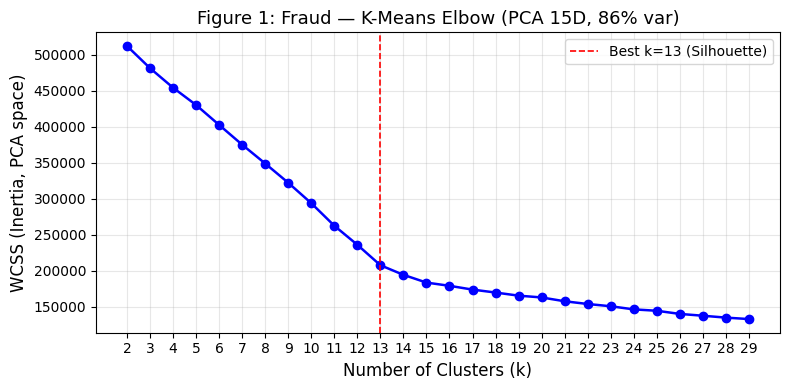

Saved: fig1_fraud_elbow.png


In [7]:
print('=' * 65)
print('FRAUD [5/9]  Elbow Plot (WCSS vs k)')
print('=' * 65)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_LIST, f_wcss, 'bo-', linewidth=1.8, markersize=6)
ax.axvline(f_best_k, color='red', linestyle='--', linewidth=1.2,
           label=f'Best k={f_best_k} (Silhouette)')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('WCSS (Inertia, PCA space)', fontsize=12)
ax.set_title(f'Figure 1: Fraud — K-Means Elbow (PCA {f_n_comp}D, {f_var_exp:.0%} var)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_xticks(K_LIST)
plt.tight_layout()
plt.savefig('fig1_fraud_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_fraud_elbow.png')

FRAUD [6/9]  Silhouette Score Plot


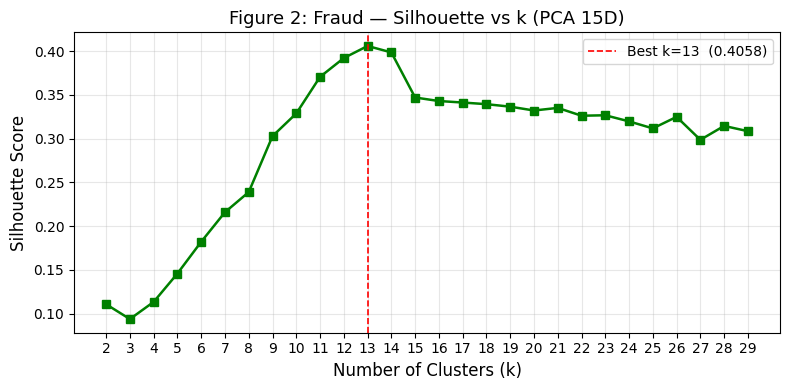

Saved: fig2_fraud_silhouette.png


In [8]:
print('=' * 65)
print('FRAUD [6/9]  Silhouette Score Plot')
print('=' * 65)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_LIST, f_sil, 'gs-', linewidth=1.8, markersize=6)
ax.axvline(f_best_k, color='red', linestyle='--', linewidth=1.2,
           label=f'Best k={f_best_k}  ({f_sil[f_best_k - 2]:.4f})')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title(f'Figure 2: Fraud — Silhouette vs k (PCA {f_n_comp}D)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_xticks(K_LIST)
plt.tight_layout()
plt.savefig('fig2_fraud_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_fraud_silhouette.png')

FRAUD [7/9]  PCA-2D Scatter — Cluster Labels vs True Labels


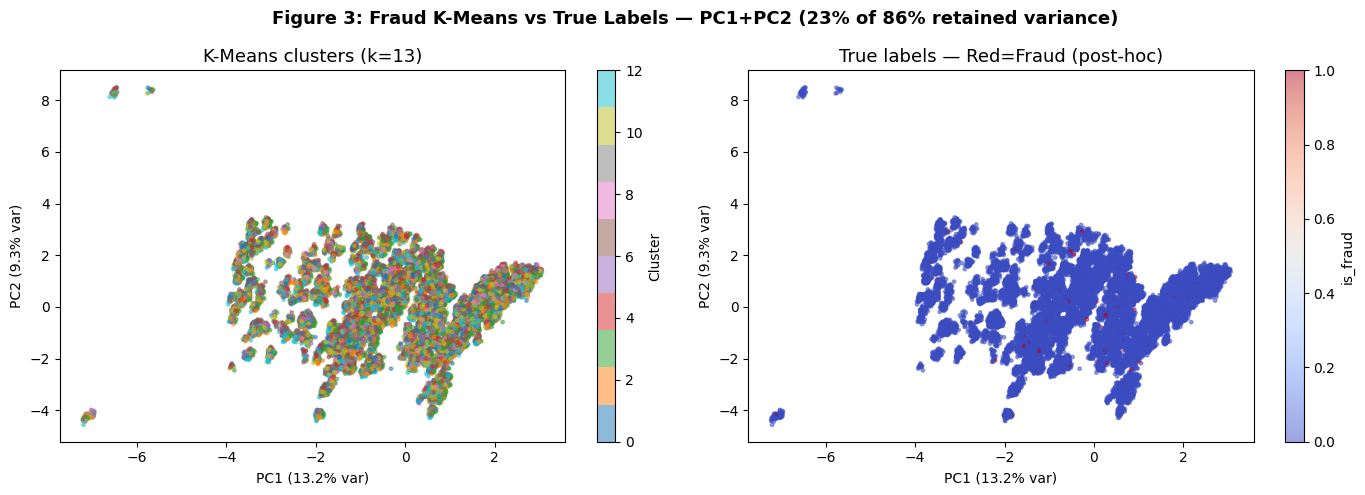

PC1+PC2 explain 22.5% of the 86% retained variance
Saved: fig3_fraud_pca2d.png


In [9]:
print('=' * 65)
print('FRAUD [7/9]  PCA-2D Scatter — Cluster Labels vs True Labels')
print('=' * 65)

km_F = KMeans(n_clusters=f_best_k, random_state=RANDOM_STATE, n_init=N_INIT)
f_cluster_labels = km_F.fit_predict(fX_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(fX_pca2d[:, 0], fX_pca2d[:, 1],
                       c=f_cluster_labels, cmap='tab10', s=6, alpha=0.5)
axes[0].set_title(f'K-Means clusters (k={f_best_k})', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pc1_var_f:.1%} var)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pc2_var_f:.1%} var)', fontsize=10)
plt.colorbar(sc0, ax=axes[0], label='Cluster')

sc1 = axes[1].scatter(fX_pca2d[:, 0], fX_pca2d[:, 1],
                       c=fy_clust.values, cmap='coolwarm', s=6, alpha=0.5)
axes[1].set_title('True labels — Red=Fraud (post-hoc)', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pc1_var_f:.1%} var)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({pc2_var_f:.1%} var)', fontsize=10)
plt.colorbar(sc1, ax=axes[1], label='is_fraud')

fig.suptitle(
    f'Figure 3: Fraud K-Means vs True Labels — PC1+PC2 '
    f'({f_pc12_var:.0%} of {f_var_exp:.0%} retained variance)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_fraud_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'PC1+PC2 explain {f_pc12_var:.1%} of the {f_var_exp:.0%} retained variance')
print('Saved: fig3_fraud_pca2d.png')

FRAUD [8/9]  Cluster Profile — Fraud Rate per Cluster
         fraud_rate  fraud_count  total_count
cluster                                      
8          0.018802           27         1436
6          0.016711           38         2274
3          0.013879           39         2810
2          0.009640           26         2697
1          0.005176            5          966
7          0.004325           13         3006
12         0.002804            3         1070
9          0.002619            5         1909
11         0.002309            5         2165
0          0.001913            4         2091
4          0.001044            2         1916
10         0.000991            5         5046
5          0.000765            2         2614

Overall fraud rate    : 0.0058
Highest-fraud cluster : 8  (rate=0.0188, lift=3.2x)


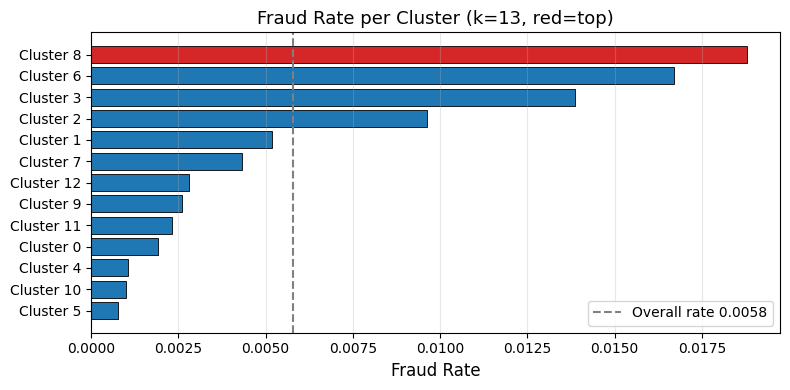

Saved: fig4_fraud_profile.png


In [10]:
print('=' * 65)
print('FRAUD [8/9]  Cluster Profile — Fraud Rate per Cluster')
print('=' * 65)

f_profile = pd.DataFrame({'cluster': f_cluster_labels, 'is_fraud': fy_clust.values})
f_cluster_stats = (f_profile.groupby('cluster')['is_fraud']
                              .agg(['mean', 'sum', 'count'])
                              .rename(columns={'mean':'fraud_rate',
                                               'sum':'fraud_count',
                                               'count':'total_count'})
                              .sort_values('fraud_rate', ascending=False))
print(f_cluster_stats.to_string())

overall_fraud_rate = fy_clust.mean()
f_top_cluster      = f_cluster_stats.index[0]
f_top_rate         = f_cluster_stats.loc[f_top_cluster, 'fraud_rate']
f_lift             = f_top_rate / overall_fraud_rate

print(f'\nOverall fraud rate    : {overall_fraud_rate:.4f}')
print(f'Highest-fraud cluster : {f_top_cluster}  '
      f'(rate={f_top_rate:.4f}, lift={f_lift:.1f}x)')

# Bar chart — fraud rate per cluster
fig, ax = plt.subplots(figsize=(8, 4))
sorted_stats = f_cluster_stats.sort_values('fraud_rate', ascending=True)
colors = ['#d62728' if i == f_top_cluster else '#1f77b4'
          for i in sorted_stats.index]
ax.barh([f'Cluster {i}' for i in sorted_stats.index],
        sorted_stats['fraud_rate'], color=colors, edgecolor='black', lw=0.6)
ax.axvline(overall_fraud_rate, color='gray', linestyle='--',
           label=f'Overall rate {overall_fraud_rate:.4f}')
ax.set_xlabel('Fraud Rate', fontsize=12)
ax.set_title(f'Fraud Rate per Cluster (k={f_best_k}, red=top)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig4_fraud_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_fraud_profile.png')

In [11]:
print('=' * 65)
print('FRAUD [9/9]  Summary + Store Results')
print('=' * 65)

wk10_results['fraud'] = {
    'n_features':      fX_clust.shape[1],
    'n_pca_comp':      f_n_comp,
    'pca_var_exp':     f_var_exp,
    'pc12_var':        f_pc12_var,
    'best_k':          f_best_k,
    'best_sil':        float(f_sil[f_best_k - 2]),
    'wcss_at_best':    float(f_wcss[f_best_k - 2]),
    'wcss_list':       f_wcss,
    'sil_list':        f_sil,
    'cluster_stats':   f_cluster_stats,
    'top_lift':        float(f_lift),
}

print(f'Features → PCA : {fX_clust.shape[1]} → {f_n_comp} components ({f_var_exp:.1%} var)')
print(f'Best k         : {f_best_k}')
print(f'Best Silhouette: {f_sil[f_best_k - 2]:.4f}')
print(f'Top cluster lift: {f_lift:.2f}x  (cluster {f_top_cluster})')
print('\nFraud results stored.')

FRAUD [9/9]  Summary + Store Results
Features → PCA : 22 → 15 components (86.5% var)
Best k         : 13
Best Silhouette: 0.4058
Top cluster lift: 3.24x  (cluster 8)

Fraud results stored.


### Fraud Detection — K-Means Analysis

**Results:** k=13, Silhouette=0.4058, top cluster lift=3.24× (Cluster 8)

**PCA pre-processing rationale:** applying PCA before K-Means serves two purposes:
(1) removes noise dimensions where signal-to-noise ratio is low, allowing K-Means to concentrate
on high-variance directions — without PCA, the curse of dimensionality causes all pairwise
Euclidean distances to converge to the same value, making cluster assignment arbitrary;
(2) ensures the 2D scatter uses the same feature space as clustering (not a separate projection
that may contradict the result). StandardScaler before PCA is required so high-variance features
do not dominate PCA directions simply due to scale.

**Why the 2D scatter does not show clean boundaries:** PC1+PC2 explain only 22.5% of total
variance. The actual clustering operates in 15-dimensional PCA space; projecting to 2D compresses
~77.5% of the geometric structure. Textbook cluster visualizations with clean convex-hull
boundaries typically use data that is natively 2D or use non-linear dimensionality reduction
(t-SNE / UMAP) designed to preserve local neighbourhood structure. PCA is a linear projection
that maximises variance, not cluster separability. The 2D scatter is useful for detecting
gross separation or overlap, not for reading precise cluster boundaries.

**Dummy variable note:** `category` (transaction type) was the top-1 feature in Week 9 GBM.
Excluding it would likely eliminate fraud-cluster signal. StandardScaler normalises dummies to
zero-mean / unit-std, partially mitigating distance distortion. The theoretically correct
alternative — K-Prototypes (mixed continuous/categorical) — falls outside the Week 10 scope.

**Cluster lift interpretation:** lift = top cluster fraud rate / overall fraud rate.
Lift=3.24× at k=13 means K-Means found a transaction-type region where fraud is 3× concentrated
without label supervision — validating the same signal that Week 9 GBM exploited via `category`.
Agreement between supervised GBM importance and unsupervised cluster lift is a strong cross-method
validation: the feature-outcome relationship is geometrically compact in Fraud.

> **Marketing context:** cluster-lift analysis is the core of behavioural segmentation —
> identifying high-conversion or high-risk segments without labels, then overlaying outcome
> rates post-hoc to validate actionability. A lift > 2× is typically the threshold for
> treating a cluster as an actionable target segment.

---
# Section 2: Credit Approval Dataset

K-Means on a 10K subsample (approval rate 99.52%).
Expected: high silhouette at k=2 — supervised AUC ≈ 0.9999 implies near-perfect separability.

In [12]:
print('=' * 65)
print('CREDIT APPROVAL [1/9]  Load & 10K Subsample')
print('=' * 65)

df_credit_raw = pd.read_csv(f'{DATA_DIR}\\credit_approval_processed.csv')
df_credit_raw.drop(columns=DROP_IDS_C, errors='ignore', inplace=True)

if len(df_credit_raw) > SAMPLE_C:
    credit_sample, _ = train_test_split(
        df_credit_raw, train_size=SAMPLE_C,
        stratify=df_credit_raw[TARGET_C], random_state=RANDOM_STATE
    )
else:
    credit_sample = df_credit_raw.copy()
credit_sample = credit_sample.reset_index(drop=True)
cy_clust = credit_sample[TARGET_C].copy()

print(f'Full dataset : {df_credit_raw.shape[0]:,} rows')
print(f'Subsample    : {credit_sample.shape[0]:,} rows  '
      f'(approval rate: {cy_clust.mean():.4f})')

CREDIT APPROVAL [1/9]  Load & 10K Subsample


Full dataset : 25,128 rows
Subsample    : 10,000 rows  (approval rate: 0.9952)


In [13]:
print('=' * 65)
print('CREDIT APPROVAL [2/9]  Encode & Feature Preparation')
print('=' * 65)

old_dummies_C = [c for c in credit_sample.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_C)]
credit_sample.drop(columns=old_dummies_C, inplace=True, errors='ignore')
for c in credit_sample.select_dtypes(exclude='number').columns:
    credit_sample[c] = credit_sample[c].astype(str).str.strip()

valid_cat_C = [c for c in CAT_COLS_C if c in credit_sample.columns]
high_card_C = [c for c in credit_sample.columns
               if c not in CAT_COLS_C and c != TARGET_C
               and not pd.api.types.is_numeric_dtype(credit_sample[c])
               and credit_sample[c].nunique() > CARDINALITY_THRESHOLD]
credit_sample.drop(columns=high_card_C, inplace=True, errors='ignore')

dum_C = pd.get_dummies(credit_sample[valid_cat_C],
                        columns=valid_cat_C, drop_first=True, dtype=int)
credit_sample = pd.concat([credit_sample, dum_C], axis=1)

cX_clust = (credit_sample.select_dtypes(include='number')
                         .drop(columns=[TARGET_C], errors='ignore').copy())
print(f'Features: {cX_clust.shape[1]}  |  Dropped (high-card): {high_card_C}')

CREDIT APPROVAL [2/9]  Encode & Feature Preparation
Features: 48  |  Dropped (high-card): []


In [14]:
print('=' * 65)
print('CREDIT APPROVAL [3/9]  StandardScaler → PCA(85%)')
print('=' * 65)

scaler_C  = StandardScaler()
cX_scaled = scaler_C.fit_transform(cX_clust)

pca_C  = PCA(n_components=PCA_VAR, svd_solver='full', random_state=RANDOM_STATE)
cX_pca = pca_C.fit_transform(cX_scaled)

c_n_comp   = cX_pca.shape[1]
c_var_exp  = float(pca_C.explained_variance_ratio_.sum())
c_pc12_var = float(pca_C.explained_variance_ratio_[:2].sum())
cX_pca2d   = cX_pca[:, :2]
pc1_var_c  = pca_C.explained_variance_ratio_[0]
pc2_var_c  = pca_C.explained_variance_ratio_[1]

print(f'Features → PCA: {cX_clust.shape[1]} → {c_n_comp} components ({c_var_exp:.1%} var)')
print(f'PC1+PC2 explain: {c_pc12_var:.1%} of total variance')

CREDIT APPROVAL [3/9]  StandardScaler → PCA(85%)
Features → PCA: 48 → 32 components (85.1% var)
PC1+PC2 explain: 11.0% of total variance


In [15]:
print('=' * 65)
print('CREDIT APPROVAL [4/9]  K-Means Sweep (k=2..11, PCA space)')
print('=' * 65)

c_wcss, c_sil = [], []
for k in K_LIST:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
    labels_k = km.fit_predict(cX_pca)
    c_wcss.append(km.inertia_)
    sil_k = silhouette_score(cX_pca, labels_k,
                              sample_size=min(3000, len(cX_pca)), random_state=RANDOM_STATE)
    c_sil.append(sil_k)
    print(f'  k={k:2d}: WCSS={km.inertia_:>12,.1f}  Silhouette={sil_k:.4f}')

c_best_k = K_LIST[int(np.argmax(c_sil))]
print(f'\nBest k (Silhouette): {c_best_k}  ({c_sil[c_best_k - 2]:.4f})')

CREDIT APPROVAL [4/9]  K-Means Sweep (k=2..11, PCA space)
  k= 2: WCSS=   378,588.8  Silhouette=0.0864
  k= 3: WCSS=   361,423.8  Silhouette=0.0837
  k= 4: WCSS=   352,161.7  Silhouette=0.0923
  k= 5: WCSS=   343,111.2  Silhouette=0.0821
  k= 6: WCSS=   333,321.5  Silhouette=0.1004
  k= 7: WCSS=   322,619.8  Silhouette=0.1120
  k= 8: WCSS=   313,672.4  Silhouette=0.0556
  k= 9: WCSS=   303,472.3  Silhouette=0.0914
  k=10: WCSS=   295,576.4  Silhouette=0.1050
  k=11: WCSS=   291,153.8  Silhouette=0.0896
  k=12: WCSS=   281,572.4  Silhouette=0.0918
  k=13: WCSS=   270,025.3  Silhouette=0.1167
  k=14: WCSS=   262,186.3  Silhouette=0.1225
  k=15: WCSS=   250,378.0  Silhouette=0.1180
  k=16: WCSS=   241,583.5  Silhouette=0.1164
  k=17: WCSS=   231,419.2  Silhouette=0.1497
  k=18: WCSS=   226,266.7  Silhouette=0.1220
  k=19: WCSS=   214,740.6  Silhouette=0.1737
  k=20: WCSS=   205,148.2  Silhouette=0.1699
  k=21: WCSS=   196,639.5  Silhouette=0.1835
  k=22: WCSS=   191,327.8  Silhouette=0.16

CREDIT APPROVAL [5/9]  Elbow Plot


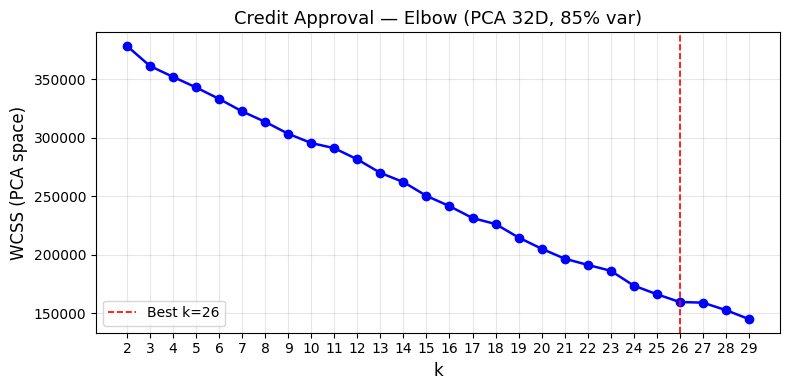

In [16]:
print('=' * 65)
print('CREDIT APPROVAL [5/9]  Elbow Plot')
print('=' * 65)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_LIST, c_wcss, 'bo-', linewidth=1.8, markersize=6)
ax.axvline(c_best_k, color='red', linestyle='--', linewidth=1.2,
           label=f'Best k={c_best_k}')
ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('WCSS (PCA space)', fontsize=12)
ax.set_title(f'Credit Approval — Elbow (PCA {c_n_comp}D, {c_var_exp:.0%} var)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_xticks(K_LIST)
plt.tight_layout(); plt.show()

CREDIT APPROVAL [6/9]  Silhouette Score Plot


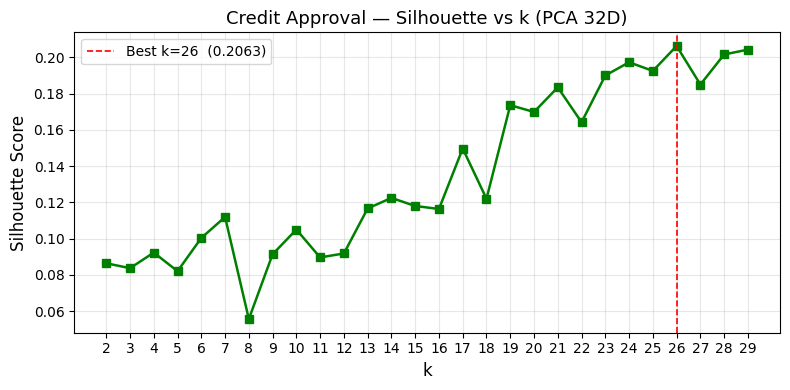

In [17]:
print('=' * 65)
print('CREDIT APPROVAL [6/9]  Silhouette Score Plot')
print('=' * 65)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_LIST, c_sil, 'gs-', linewidth=1.8, markersize=6)
ax.axvline(c_best_k, color='red', linestyle='--', linewidth=1.2,
           label=f'Best k={c_best_k}  ({c_sil[c_best_k - 2]:.4f})')
ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title(f'Credit Approval — Silhouette vs k (PCA {c_n_comp}D)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_xticks(K_LIST)
plt.tight_layout(); plt.show()

CREDIT APPROVAL [7/9]  PCA-2D Scatter


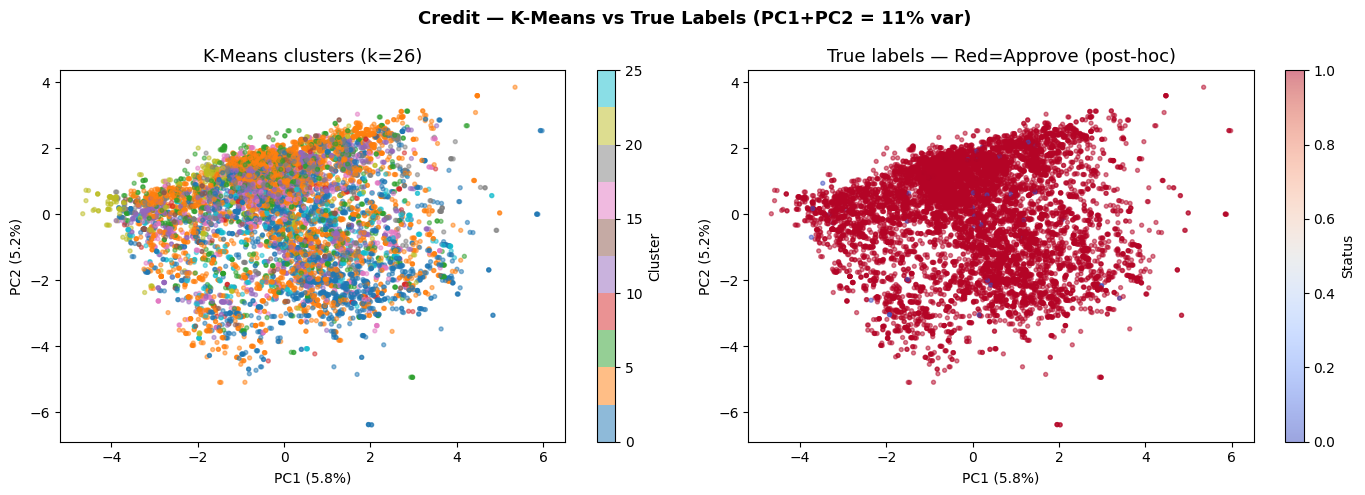

Saved: fig5_credit_pca2d.png


In [18]:
print('=' * 65)
print('CREDIT APPROVAL [7/9]  PCA-2D Scatter')
print('=' * 65)

km_C = KMeans(n_clusters=c_best_k, random_state=RANDOM_STATE, n_init=N_INIT)
c_cluster_labels = km_C.fit_predict(cX_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc0 = axes[0].scatter(cX_pca2d[:, 0], cX_pca2d[:, 1],
                       c=c_cluster_labels, cmap='tab10', s=8, alpha=0.5)
axes[0].set_title(f'K-Means clusters (k={c_best_k})', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pc1_var_c:.1%})', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pc2_var_c:.1%})', fontsize=10)
plt.colorbar(sc0, ax=axes[0], label='Cluster')

sc1 = axes[1].scatter(cX_pca2d[:, 0], cX_pca2d[:, 1],
                       c=cy_clust.values, cmap='coolwarm', s=8, alpha=0.5)
axes[1].set_title('True labels — Red=Approve (post-hoc)', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pc1_var_c:.1%})', fontsize=10)
axes[1].set_ylabel(f'PC2 ({pc2_var_c:.1%})', fontsize=10)
plt.colorbar(sc1, ax=axes[1], label=TARGET_C)

fig.suptitle(f'Credit — K-Means vs True Labels (PC1+PC2 = {c_pc12_var:.0%} var)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_credit_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_credit_pca2d.png')

CREDIT APPROVAL [8/9]  Cluster Profile — Approval Rate
         approval_rate  approved_count  total_count
cluster                                            
14            1.000000             161          161
12            1.000000              31           31
18            1.000000             249          249
17            1.000000              53           53
25            1.000000               5            5
21            1.000000              36           36
19            0.998110             528          529
15            0.997942             485          486
3             0.997120            2077         2083
24            0.996700             302          303
10            0.996624            1181         1185
4             0.996257            1331         1336
2             0.994368            1236         1243
7             0.993952             493          496
23            0.993939             164          165
1             0.992925             421          424
5        

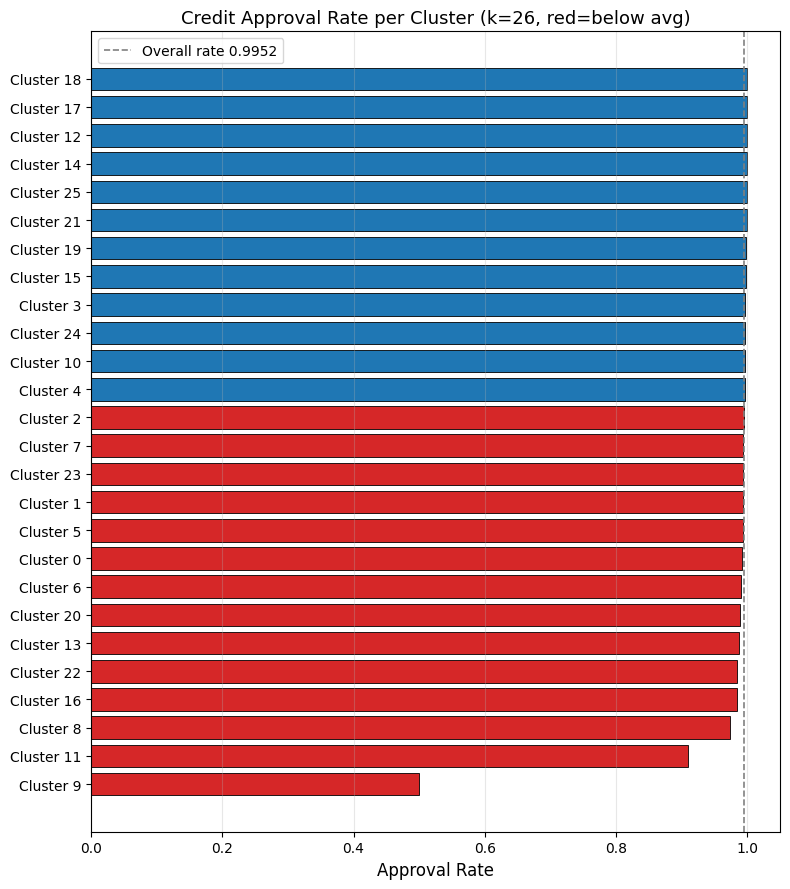

Saved: fig7_credit_profile.png


In [19]:
print('=' * 65)
print('CREDIT APPROVAL [8/9]  Cluster Profile — Approval Rate')
print('=' * 65)

c_profile = pd.DataFrame({'cluster': c_cluster_labels, TARGET_C: cy_clust.values})
c_cluster_stats = (c_profile.groupby('cluster')[TARGET_C]
                              .agg(['mean', 'sum', 'count'])
                              .rename(columns={'mean':'approval_rate',
                                               'sum':'approved_count',
                                               'count':'total_count'})
                              .sort_values('approval_rate', ascending=False))
print(c_cluster_stats.to_string())

overall_approval = cy_clust.mean()
rate_range = (c_cluster_stats['approval_rate'].max()
              - c_cluster_stats['approval_rate'].min())
print(f'\nOverall approval rate : {overall_approval:.4f}')
print(f'Rate spread across clusters: {rate_range:.4f}')

# Bar chart — approval rate per cluster
fig, ax = plt.subplots(figsize=(8, 9))
sorted_c = c_cluster_stats.sort_values('approval_rate', ascending=True)
c_bar_colors = ['#d62728' if sorted_c.loc[i, 'approval_rate'] < overall_approval
                else '#1f77b4' for i in sorted_c.index]
ax.barh([f'Cluster {i}' for i in sorted_c.index],
        sorted_c['approval_rate'], color=c_bar_colors, edgecolor='black', lw=0.6)
ax.axvline(overall_approval, color='gray', linestyle='--', linewidth=1.2,
           label=f'Overall rate {overall_approval:.4f}')
ax.set_xlabel('Approval Rate', fontsize=12)
ax.set_title(f'Credit Approval Rate per Cluster (k={c_best_k}, red=below avg)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig7_credit_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig7_credit_profile.png')

In [20]:
print('=' * 65)
print('CREDIT APPROVAL [9/9]  Summary + Store')
print('=' * 65)

wk10_results['credit'] = {
    'n_features':    cX_clust.shape[1],
    'n_pca_comp':    c_n_comp,
    'pca_var_exp':   c_var_exp,
    'pc12_var':      c_pc12_var,
    'best_k':        c_best_k,
    'best_sil':      float(c_sil[c_best_k - 2]),
    'wcss_at_best':  float(c_wcss[c_best_k - 2]),
    'wcss_list':     c_wcss,
    'sil_list':      c_sil,
    'cluster_stats': c_cluster_stats,
}
print(f'Features → PCA : {cX_clust.shape[1]} → {c_n_comp} ({c_var_exp:.1%} var)')
print(f'Best k         : {c_best_k}  |  Silhouette: {c_sil[c_best_k - 2]:.4f}')
print('Credit results stored.')

CREDIT APPROVAL [9/9]  Summary + Store
Features → PCA : 48 → 32 (85.1% var)
Best k         : 26  |  Silhouette: 0.2063
Credit results stored.


### Credit Approval — K-Means Analysis

**Actual outcome vs expectation:** supervised AUC 0.9999 implied near-perfect separability, so
k=2 with a high silhouette was predicted. Instead: best k=26, silhouette=0.2063 — the weakest
cluster structure across all three datasets. This divergence is the most analytically interesting
finding in Week 10.

**Why k=2 did not emerge:** 99.52% approval rate means K-Means has almost no class variation to
partition. At k=2, silhouette=0.0864 — the lowest value in the entire sweep. The feature vectors
for approved and rejected applicants overlap heavily in PCA space (PC1+PC2 explain only 11.0% of
variance, confirming a highly diffuse, high-dimensional feature space). K-Means iterates toward
geometric cluster centres, but there is no geometric boundary corresponding to the approval decision.

**Why supervised AUC ≠ unsupervised silhouette:** ROC-AUC=0.9999 means a *trained* classifier can
perfectly rank applicants by a learned decision boundary. K-Means has no label to guide separation —
it sees only Euclidean geometry. The near-perfect AUC is partly an artifact of class imbalance
(predicting "approve" for everything achieves ~99.5% accuracy); the discriminative power comes from
a handful of strong socioeconomic features, not from geometrically compact class clusters.

**PCA dimensionality:** 48 features → 32 PCA components (85.1% variance). More components than
Fraud (22→15) despite a simpler domain, because one-hot encoding of six categorical variables
spreads variance across many low-signal dimensions.

> **Critical finding:** high supervised discriminability does NOT imply high unsupervised cluster
> structure. In marketing lead scoring, this means a feature set that powers a great classifier
> may still fail to produce actionable segments — you need a supervised model, not clustering,
> when the minority class is too rare to form a geometric island.

---
# Section 3: Loan Default Dataset

K-Means on a **15K** subsample (default rate 18.89% → ~2,835 default rows).
Expected: low silhouette, weak cluster–label alignment — consistent with supervised AUC ~0.70 ceiling.

In [21]:
print('=' * 65)
print('LOAN DEFAULT [1/9]  Load & 15K Subsample')
print('=' * 65)

df_loan_raw = pd.read_csv(f'{DATA_DIR}\\loan_default_processed.csv')
df_loan_raw.drop(columns=DROP_IDS_L + ['Designation'], errors='ignore', inplace=True)

if len(df_loan_raw) > SAMPLE_L:
    loan_sample, _ = train_test_split(
        df_loan_raw, train_size=SAMPLE_L,
        stratify=df_loan_raw[TARGET_L], random_state=RANDOM_STATE
    )
else:
    loan_sample = df_loan_raw.copy()
loan_sample = loan_sample.reset_index(drop=True)
ly_clust = loan_sample[TARGET_L].copy()

print(f'Full dataset : {df_loan_raw.shape[0]:,} rows')
print(f'Subsample    : {loan_sample.shape[0]:,} rows  '
      f'(default rate: {ly_clust.mean():.4f})')
print(f'Default count: {ly_clust.sum():,}')

LOAN DEFAULT [1/9]  Load & 15K Subsample
Full dataset : 68,505 rows
Subsample    : 15,000 rows  (default rate: 0.1889)
Default count: 2,833


In [22]:
print('=' * 65)
print('LOAN DEFAULT [2/9]  Encode & Feature Preparation')
print('=' * 65)

old_dummies_L = [c for c in loan_sample.columns
                 if any(c.strip().startswith(f'{cat}_') for cat in CAT_COLS_L)]
loan_sample.drop(columns=old_dummies_L, inplace=True, errors='ignore')
for c in loan_sample.select_dtypes(exclude='number').columns:
    loan_sample[c] = loan_sample[c].astype(str).str.strip()

valid_cat_L = [c for c in CAT_COLS_L if c in loan_sample.columns]
high_card_L = [c for c in loan_sample.columns
               if c not in CAT_COLS_L and c != TARGET_L
               and not pd.api.types.is_numeric_dtype(loan_sample[c])
               and loan_sample[c].nunique() > CARDINALITY_THRESHOLD]
loan_sample.drop(columns=high_card_L, inplace=True, errors='ignore')

dum_L = pd.get_dummies(loan_sample[valid_cat_L],
                        columns=valid_cat_L, drop_first=True, dtype=int)
loan_sample = pd.concat([loan_sample, dum_L], axis=1)

lX_clust = (loan_sample.select_dtypes(include='number')
                       .drop(columns=[TARGET_L], errors='ignore').copy())
print(f'Features: {lX_clust.shape[1]}  |  Dropped (high-card): {high_card_L}')

LOAN DEFAULT [2/9]  Encode & Feature Preparation
Features: 53  |  Dropped (high-card): []


In [23]:
print('=' * 65)
print('LOAN DEFAULT [3/9]  StandardScaler → PCA(85%)')
print('=' * 65)

scaler_L  = StandardScaler()
lX_scaled = scaler_L.fit_transform(lX_clust)

pca_L  = PCA(n_components=PCA_VAR, svd_solver='full', random_state=RANDOM_STATE)
lX_pca = pca_L.fit_transform(lX_scaled)

l_n_comp   = lX_pca.shape[1]
l_var_exp  = float(pca_L.explained_variance_ratio_.sum())
l_pc12_var = float(pca_L.explained_variance_ratio_[:2].sum())
lX_pca2d   = lX_pca[:, :2]
pc1_var_l  = pca_L.explained_variance_ratio_[0]
pc2_var_l  = pca_L.explained_variance_ratio_[1]

print(f'Features → PCA: {lX_clust.shape[1]} → {l_n_comp} components ({l_var_exp:.1%} var)')
print(f'PC1+PC2 explain: {l_pc12_var:.1%} of total variance')

LOAN DEFAULT [3/9]  StandardScaler → PCA(85%)
Features → PCA: 53 → 37 components (85.6% var)
PC1+PC2 explain: 11.1% of total variance


In [24]:
print('=' * 65)
print('LOAN DEFAULT [4/9]  K-Means Sweep (k=2..11, PCA space)')
print('=' * 65)

l_wcss, l_sil = [], []
for k in K_LIST:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT)
    labels_k = km.fit_predict(lX_pca)
    l_wcss.append(km.inertia_)
    sil_k = silhouette_score(lX_pca, labels_k,
                              sample_size=min(3000, len(lX_pca)), random_state=RANDOM_STATE)
    l_sil.append(sil_k)
    print(f'  k={k:2d}: WCSS={km.inertia_:>12,.1f}  Silhouette={sil_k:.4f}')

l_best_k = K_LIST[int(np.argmax(l_sil))]
print(f'\nBest k (Silhouette): {l_best_k}  ({l_sil[l_best_k - 2]:.4f})')

LOAN DEFAULT [4/9]  K-Means Sweep (k=2..11, PCA space)
  k= 2: WCSS=   649,925.6  Silhouette=0.0523
  k= 3: WCSS=   628,004.9  Silhouette=0.0534
  k= 4: WCSS=   609,515.3  Silhouette=0.0408
  k= 5: WCSS=   596,028.2  Silhouette=0.0343
  k= 6: WCSS=   581,124.1  Silhouette=0.0410
  k= 7: WCSS=   566,786.6  Silhouette=0.0642
  k= 8: WCSS=   556,928.6  Silhouette=0.0854
  k= 9: WCSS=   538,548.2  Silhouette=0.0707
  k=10: WCSS=   531,236.8  Silhouette=0.0558
  k=11: WCSS=   513,599.9  Silhouette=0.0698
  k=12: WCSS=   503,011.8  Silhouette=0.0822
  k=13: WCSS=   485,076.7  Silhouette=0.0939
  k=14: WCSS=   476,962.6  Silhouette=0.0886
  k=15: WCSS=   470,755.6  Silhouette=0.1026
  k=16: WCSS=   456,597.1  Silhouette=0.0894
  k=17: WCSS=   437,307.5  Silhouette=0.0933
  k=18: WCSS=   432,243.3  Silhouette=0.0992
  k=19: WCSS=   414,804.1  Silhouette=0.0998
  k=20: WCSS=   405,042.3  Silhouette=0.1131
  k=21: WCSS=   391,834.6  Silhouette=0.1286
  k=22: WCSS=   382,525.0  Silhouette=0.1159


LOAN DEFAULT [5/9]  Elbow Plot


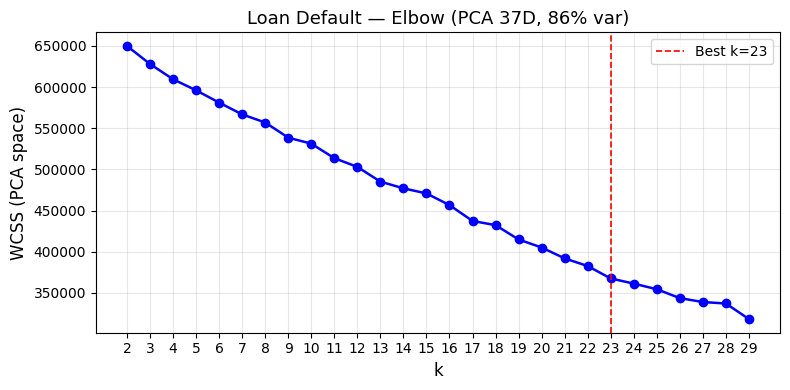

In [25]:
print('=' * 65)
print('LOAN DEFAULT [5/9]  Elbow Plot')
print('=' * 65)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_LIST, l_wcss, 'bo-', linewidth=1.8, markersize=6)
ax.axvline(l_best_k, color='red', linestyle='--', linewidth=1.2,
           label=f'Best k={l_best_k}')
ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('WCSS (PCA space)', fontsize=12)
ax.set_title(f'Loan Default — Elbow (PCA {l_n_comp}D, {l_var_exp:.0%} var)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_xticks(K_LIST)
plt.tight_layout(); plt.show()

LOAN DEFAULT [6/9]  Silhouette Score Plot


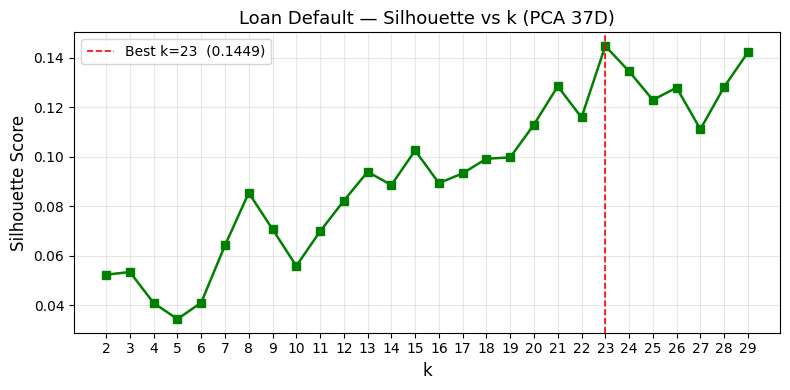

In [26]:
print('=' * 65)
print('LOAN DEFAULT [6/9]  Silhouette Score Plot')
print('=' * 65)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_LIST, l_sil, 'gs-', linewidth=1.8, markersize=6)
ax.axvline(l_best_k, color='red', linestyle='--', linewidth=1.2,
           label=f'Best k={l_best_k}  ({l_sil[l_best_k - 2]:.4f})')
ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title(f'Loan Default — Silhouette vs k (PCA {l_n_comp}D)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_xticks(K_LIST)
plt.tight_layout(); plt.show()

LOAN DEFAULT [7/9]  PCA-2D Scatter


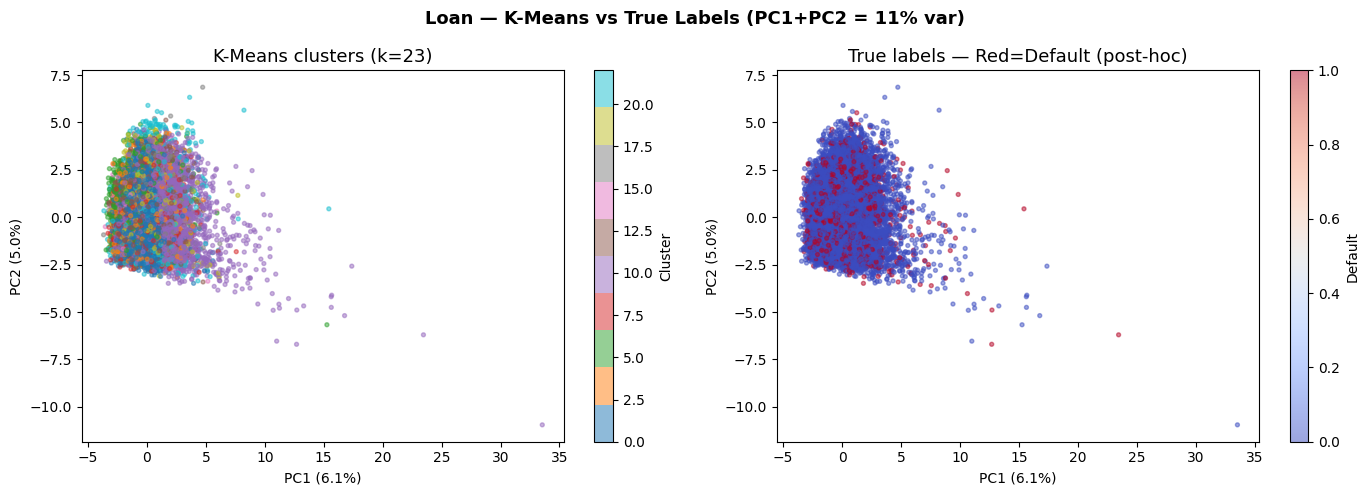

Saved: fig6_loan_pca2d.png


In [27]:
print('=' * 65)
print('LOAN DEFAULT [7/9]  PCA-2D Scatter')
print('=' * 65)

km_L = KMeans(n_clusters=l_best_k, random_state=RANDOM_STATE, n_init=N_INIT)
l_cluster_labels = km_L.fit_predict(lX_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc0 = axes[0].scatter(lX_pca2d[:, 0], lX_pca2d[:, 1],
                       c=l_cluster_labels, cmap='tab10', s=8, alpha=0.5)
axes[0].set_title(f'K-Means clusters (k={l_best_k})', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pc1_var_l:.1%})', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pc2_var_l:.1%})', fontsize=10)
plt.colorbar(sc0, ax=axes[0], label='Cluster')

sc1 = axes[1].scatter(lX_pca2d[:, 0], lX_pca2d[:, 1],
                       c=ly_clust.values, cmap='coolwarm', s=8, alpha=0.5)
axes[1].set_title('True labels — Red=Default (post-hoc)', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pc1_var_l:.1%})', fontsize=10)
axes[1].set_ylabel(f'PC2 ({pc2_var_l:.1%})', fontsize=10)
plt.colorbar(sc1, ax=axes[1], label=TARGET_L)

fig.suptitle(f'Loan — K-Means vs True Labels (PC1+PC2 = {l_pc12_var:.0%} var)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_loan_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig6_loan_pca2d.png')

LOAN DEFAULT [8/9]  Cluster Profile — Default Rate
         default_rate  default_count  total_count
cluster                                          
2            1.000000              1            1
16           0.700000              7           10
11           0.351852             19           54
19           0.233279            143          613
0            0.231405            168          726
15           0.229508             14           61
17           0.205273            109          531
18           0.204225             29          142
7            0.202429             50          247
13           0.195962            165          842
1            0.194984            863         4426
9            0.192586            213         1106
20           0.192000             24          125
4            0.191489             27          141
21           0.185507            128          690
8            0.185379            142          766
12           0.184524            124          672

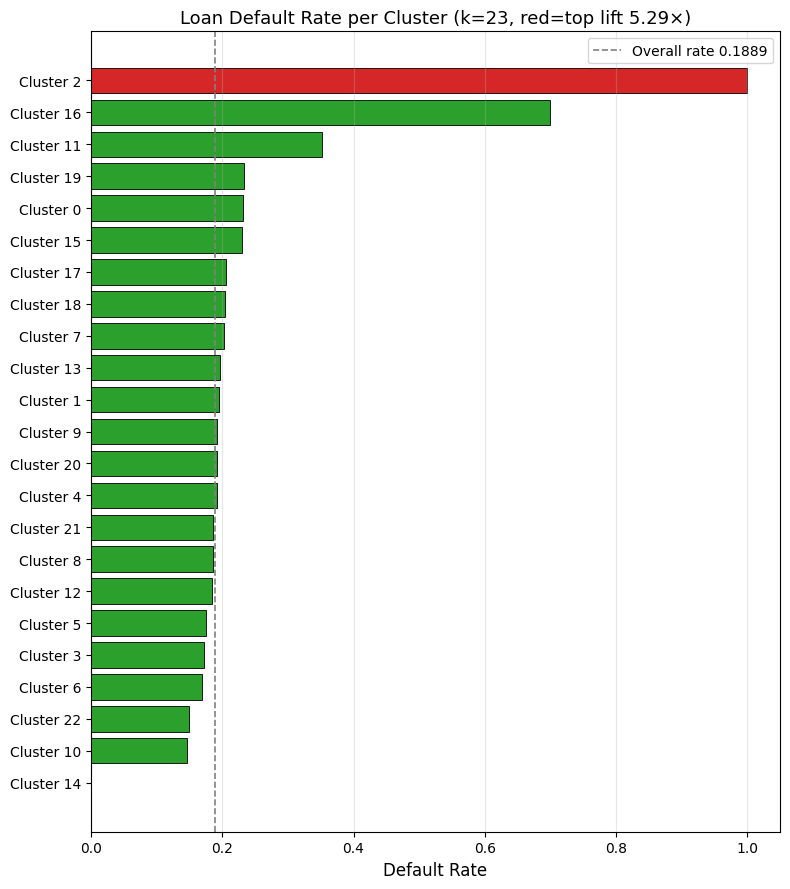

Saved: fig8_loan_profile.png


In [28]:
print('=' * 65)
print('LOAN DEFAULT [8/9]  Cluster Profile — Default Rate')
print('=' * 65)

l_profile = pd.DataFrame({'cluster': l_cluster_labels, TARGET_L: ly_clust.values})
l_cluster_stats = (l_profile.groupby('cluster')[TARGET_L]
                              .agg(['mean', 'sum', 'count'])
                              .rename(columns={'mean':'default_rate',
                                               'sum':'default_count',
                                               'count':'total_count'})
                              .sort_values('default_rate', ascending=False))
print(l_cluster_stats.to_string())

overall_default  = ly_clust.mean()
l_top_cluster    = l_cluster_stats.index[0]
l_top_rate       = l_cluster_stats.loc[l_top_cluster, 'default_rate']
l_lift           = l_top_rate / overall_default
print(f'\nOverall default rate  : {overall_default:.4f}')
print(f'Top cluster lift      : {l_lift:.2f}x  (cluster {l_top_cluster})')

# Bar chart — default rate per cluster
fig, ax = plt.subplots(figsize=(8, 9))
sorted_l = l_cluster_stats.sort_values('default_rate', ascending=True)
l_bar_colors = ['#d62728' if i == l_top_cluster else '#2ca02c' for i in sorted_l.index]
ax.barh([f'Cluster {i}' for i in sorted_l.index],
        sorted_l['default_rate'], color=l_bar_colors, edgecolor='black', lw=0.6)
ax.axvline(overall_default, color='gray', linestyle='--', linewidth=1.2,
           label=f'Overall rate {overall_default:.4f}')
ax.set_xlabel('Default Rate', fontsize=12)
ax.set_title(f'Loan Default Rate per Cluster (k={l_best_k}, red=top lift {l_lift:.2f}×)', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig8_loan_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig8_loan_profile.png')

In [29]:
print('=' * 65)
print('LOAN DEFAULT [9/9]  Summary + Store')
print('=' * 65)

wk10_results['loan'] = {
    'n_features':    lX_clust.shape[1],
    'n_pca_comp':    l_n_comp,
    'pca_var_exp':   l_var_exp,
    'pc12_var':      l_pc12_var,
    'best_k':        l_best_k,
    'best_sil':      float(l_sil[l_best_k - 2]),
    'wcss_at_best':  float(l_wcss[l_best_k - 2]),
    'wcss_list':     l_wcss,
    'sil_list':      l_sil,
    'cluster_stats': l_cluster_stats,
    'top_lift':      float(l_lift),
}
print(f'Features → PCA : {lX_clust.shape[1]} → {l_n_comp} ({l_var_exp:.1%} var)')
print(f'Best k         : {l_best_k}  |  Silhouette: {l_sil[l_best_k - 2]:.4f}')
print(f'Top cluster lift: {l_lift:.2f}x')
print('Loan results stored.')

LOAN DEFAULT [9/9]  Summary + Store
Features → PCA : 53 → 37 (85.6% var)
Best k         : 23  |  Silhouette: 0.1449
Top cluster lift: 5.29x
Loan results stored.


### Loan Default — K-Means Analysis

**Actual outcome:** best k=23, silhouette=0.1449 — low but not negligible. Loan has the weakest
cluster structure across the three datasets, consistent with the supervised AUC ceiling (~0.70).

**Silhouette vs lift tension:** top cluster lift=5.29× sounds strong, but cluster 2 has n=1 (a
single isolated outlier). High lift in a size-1 cluster is a sampling artifact, not a meaningful
pattern. The silhouette score of 0.1449 is the honest summary: clusters are barely distinguishable
from each other, confirming that default signal is diffuse across the feature space.

**Confirmed ceiling:** every supervised model from Weeks 1–9 (AUC range 0.69–0.70) and now
unsupervised K-Means converge on the same wall. The limitation is data quality — missing payment
history, credit bureau signals, and behavioural indicators — not the algorithm family. K-Means
reaches the ceiling because the features simply do not encode a geometric boundary between defaulters
and non-defaulters.

**PCA dimensionality:** 53 features → 37 components (85.6% variance). Highest component count
across all three datasets, indicating the highest-noise, most diffuse feature space. More
dimensions retained means more directions of residual variance — each holding a small piece of
signal scattered across many decorrelated axes.

> **Marketing context:** low silhouette on loan default confirms that behavioural segmentation
> on static application features cannot identify churn-risk customers. Richer temporal data
> (payment delays, login frequency, support tickets) would be needed before unsupervised risk
> tiers become actionable — the same "invest in data, not algorithms" conclusion as Week 9 GBM.

---
# Part 4: Combined Cross-Dataset Figures

PART 4 — Figure A: PCA Dimensionality Reduction Summary


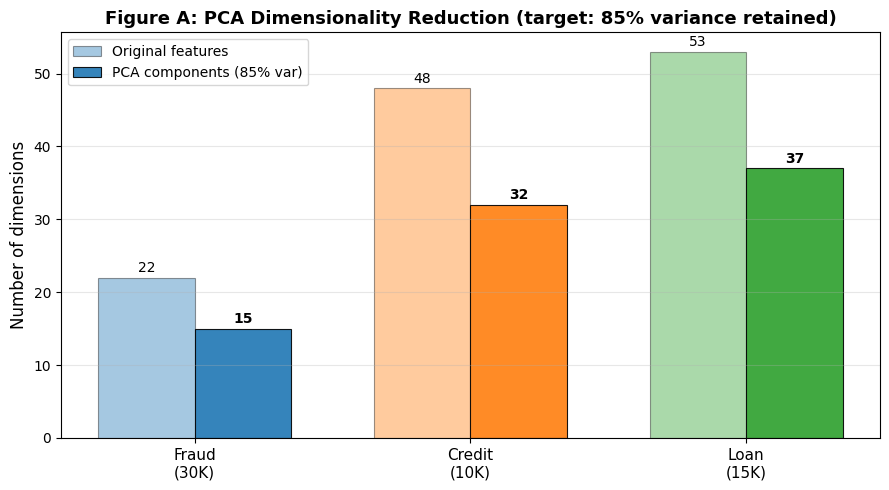

Saved: figA_pca_summary.png


In [30]:
print('=' * 65)
print('PART 4 — Figure A: PCA Dimensionality Reduction Summary')
print('=' * 65)

datasets  = ['Fraud\n(30K)', 'Credit\n(10K)', 'Loan\n(15K)']
n_feats   = [wk10_results['fraud']['n_features'],
             wk10_results['credit']['n_features'],
             wk10_results['loan']['n_features']]
n_comps   = [wk10_results['fraud']['n_pca_comp'],
             wk10_results['credit']['n_pca_comp'],
             wk10_results['loan']['n_pca_comp']]
colors    = ['#1f77b4', '#ff7f0e', '#2ca02c']

x = np.arange(len(datasets))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, n_feats, width, label='Original features',
               color=colors, alpha=0.4, edgecolor='black', lw=0.8)
bars2 = ax.bar(x + width/2, n_comps, width, label=f'PCA components ({PCA_VAR:.0%} var)',
               color=colors, alpha=0.9, edgecolor='black', lw=0.8)
for bar, v in zip(bars1, n_feats):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v),
            ha='center', va='bottom', fontsize=10)
for bar, v in zip(bars2, n_comps):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v),
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(datasets, fontsize=11)
ax.set_ylabel('Number of dimensions', fontsize=12)
ax.set_title(f'Figure A: PCA Dimensionality Reduction (target: {PCA_VAR:.0%} variance retained)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figA_pca_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figA_pca_summary.png')

PART 4 — Figure B: WCSS Elbow Curves (3-panel)


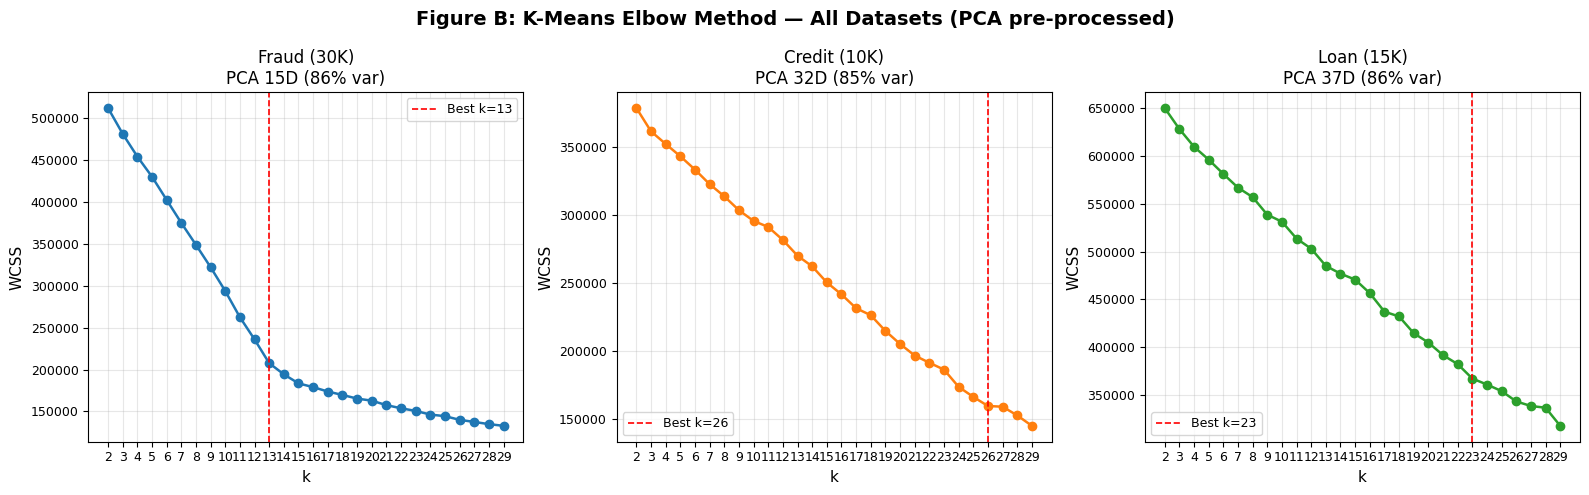

Saved: figB_elbow_all.png


In [31]:
print('=' * 65)
print('PART 4 — Figure B: WCSS Elbow Curves (3-panel)')
print('=' * 65)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [
    ('Fraud (30K)',   'fraud',  '#1f77b4', f_wcss, f_best_k, f_n_comp, f_var_exp),
    ('Credit (10K)',  'credit', '#ff7f0e', c_wcss, c_best_k, c_n_comp, c_var_exp),
    ('Loan (15K)',    'loan',   '#2ca02c', l_wcss, l_best_k, l_n_comp, l_var_exp),
]
for ax, (title, ds, color, wcss, bk, ncomp, vexp) in zip(axes, panels):
    ax.plot(K_LIST, wcss, 'o-', color=color, linewidth=1.8, markersize=6)
    ax.axvline(bk, color='red', linestyle='--', linewidth=1.2, label=f'Best k={bk}')
    ax.set_xlabel('k', fontsize=11)
    ax.set_ylabel('WCSS', fontsize=11)
    ax.set_title(f'{title}\nPCA {ncomp}D ({vexp:.0%} var)', fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xticks(K_LIST)
    ax.tick_params(labelsize=9)

fig.suptitle('Figure B: K-Means Elbow Method — All Datasets (PCA pre-processed)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figB_elbow_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figB_elbow_all.png')

PART 4 — Figure C: Silhouette Scores (3-panel)


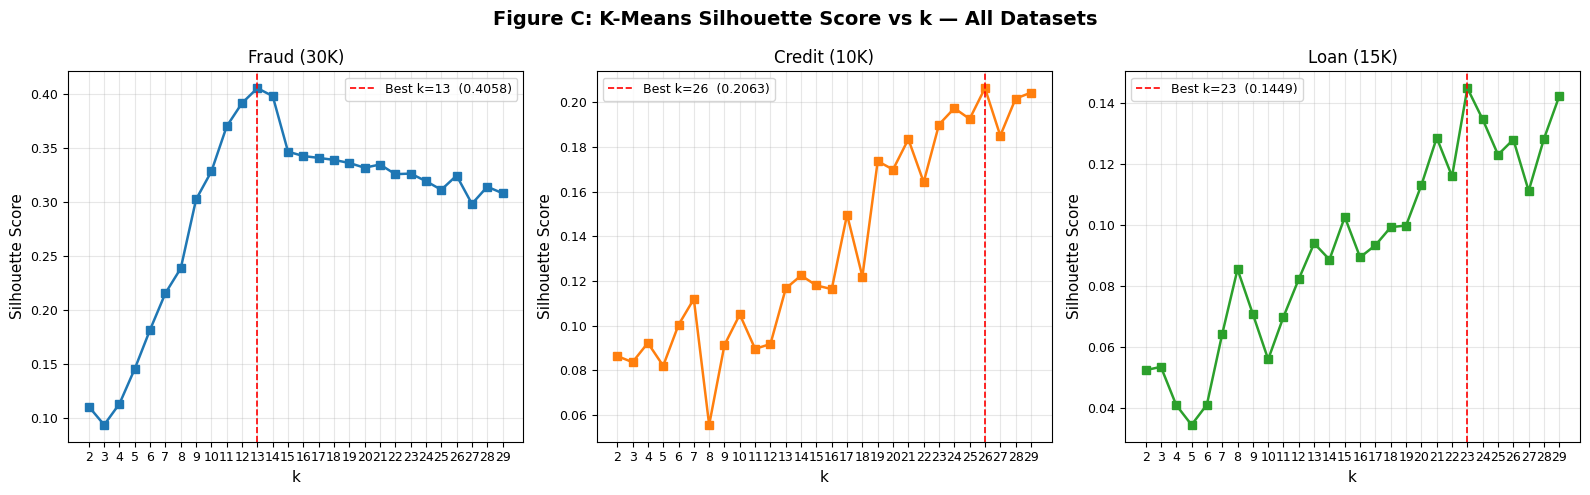

Saved: figC_silhouette_all.png


In [32]:
print('=' * 65)
print('PART 4 — Figure C: Silhouette Scores (3-panel)')
print('=' * 65)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels2 = [
    ('Fraud (30K)',  '#1f77b4', f_sil, f_best_k),
    ('Credit (10K)', '#ff7f0e', c_sil, c_best_k),
    ('Loan (15K)',   '#2ca02c', l_sil, l_best_k),
]
for ax, (title, color, sil, bk) in zip(axes, panels2):
    ax.plot(K_LIST, sil, 's-', color=color, linewidth=1.8, markersize=6)
    ax.axvline(bk, color='red', linestyle='--', linewidth=1.2,
               label=f'Best k={bk}  ({sil[bk - 2]:.4f})')
    ax.set_xlabel('k', fontsize=11)
    ax.set_ylabel('Silhouette Score', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xticks(K_LIST)
    ax.tick_params(labelsize=9)

fig.suptitle('Figure C: K-Means Silhouette Score vs k — All Datasets',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figC_silhouette_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figC_silhouette_all.png')

PART 4 — Figure D: Cluster Profiles — All Datasets (3-panel)


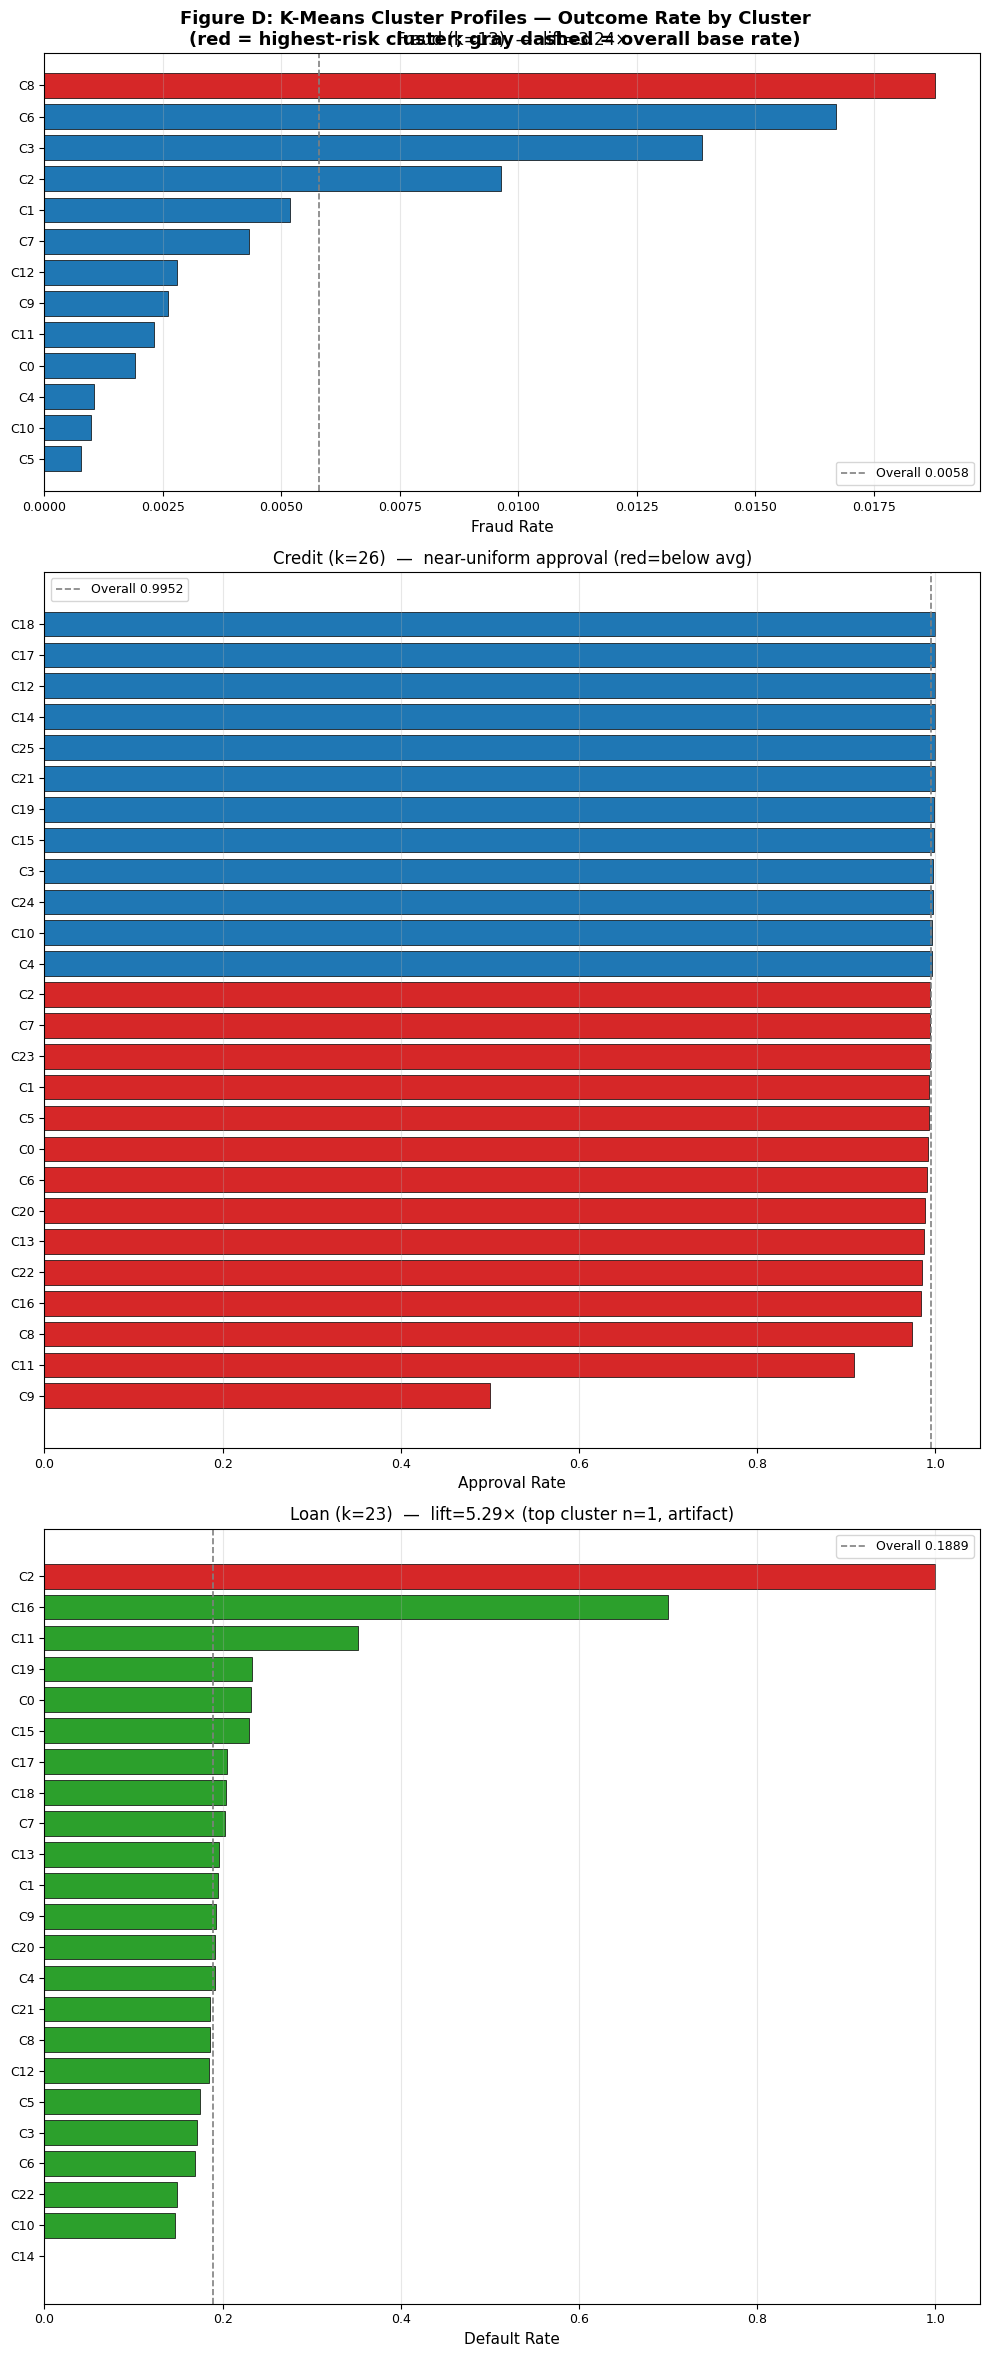

Saved: figD_profile_all.png


In [33]:
print('=' * 65)
print('PART 4 — Figure D: Cluster Profiles — All Datasets (3-panel)')
print('=' * 65)

fig, axes = plt.subplots(3, 1, figsize=(10, 24),
                         gridspec_kw={'height_ratios': [
                             wk10_results['fraud']['best_k'],
                             wk10_results['credit']['best_k'],
                             wk10_results['loan']['best_k'],
                         ]})

# --- Fraud ---
f_sorted = f_cluster_stats.sort_values('fraud_rate', ascending=True)
fd_colors = ['#d62728' if i == f_top_cluster else '#1f77b4'
             for i in f_sorted.index]
axes[0].barh([f'C{i}' for i in f_sorted.index],
             f_sorted['fraud_rate'], color=fd_colors, edgecolor='black', lw=0.5)
axes[0].axvline(overall_fraud_rate, color='gray', linestyle='--', lw=1.2,
                label=f'Overall {overall_fraud_rate:.4f}')
axes[0].set_xlabel('Fraud Rate', fontsize=11)
axes[0].set_title(f'Fraud (k={f_best_k})  —  lift={f_lift:.2f}×', fontsize=12)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='x')
axes[0].tick_params(labelsize=9)

# --- Credit ---
c_sorted = c_cluster_stats.sort_values('approval_rate', ascending=True)
cd_colors = ['#d62728' if c_sorted.loc[i, 'approval_rate'] < overall_approval
             else '#1f77b4' for i in c_sorted.index]
axes[1].barh([f'C{i}' for i in c_sorted.index],
             c_sorted['approval_rate'], color=cd_colors, edgecolor='black', lw=0.5)
axes[1].axvline(overall_approval, color='gray', linestyle='--', lw=1.2,
                label=f'Overall {overall_approval:.4f}')
axes[1].set_xlabel('Approval Rate', fontsize=11)
axes[1].set_title(f'Credit (k={c_best_k})  —  near-uniform approval (red=below avg)',
                  fontsize=12)
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='x')
axes[1].tick_params(labelsize=9)

# --- Loan ---
l_sorted = l_cluster_stats.sort_values('default_rate', ascending=True)
ld_colors = ['#d62728' if i == l_top_cluster else '#2ca02c'
             for i in l_sorted.index]
axes[2].barh([f'C{i}' for i in l_sorted.index],
             l_sorted['default_rate'], color=ld_colors, edgecolor='black', lw=0.5)
axes[2].axvline(overall_default, color='gray', linestyle='--', lw=1.2,
                label=f'Overall {overall_default:.4f}')
axes[2].set_xlabel('Default Rate', fontsize=11)
axes[2].set_title(f'Loan (k={l_best_k})  —  lift={l_lift:.2f}× (top cluster n=1, artifact)',
                  fontsize=12)
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3, axis='x')
axes[2].tick_params(labelsize=9)

fig.suptitle(
    'Figure D: K-Means Cluster Profiles — Outcome Rate by Cluster\n'
    '(red = highest-risk cluster; gray dashed = overall base rate)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figD_profile_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figD_profile_all.png')

---
### Week 10 Cross-Dataset Summary

**Results at a glance:**

| Dataset | Features→PCA | PC1+PC2 | Best k | Silhouette | Top lift |
|---|---|---|---|---|---|
| Fraud (30K) | 22 → 15 (86.5%) | 22.5% | 13 | **0.4058** | 3.24× |
| Credit (10K) | 48 → 32 (85.1%) | 11.0% | 26 | 0.2063 | — |
| Loan (15K) | 53 → 37 (85.6%) | 11.1% | 23 | 0.1449 | 5.29×† |

†Loan top cluster n=1 (artifact — single outlier, not a real pattern)

---

**Finding 1 — Silhouette does NOT mirror supervised AUC ranking:**

Supervised AUC: Credit (0.9999) > Fraud (0.9825) > Loan (0.7030)
Unsupervised silhouette: Fraud (0.4058) > Credit (0.2063) > Loan (0.1449)

The inversion for Credit is the central insight: AUC=0.9999 is an artifact of 99.52% class
imbalance (predicting "approve" always achieves ~99.5% accuracy), not geometric separability.
K-Means has no label — it sees only Euclidean structure — and finds no binary cluster because
approved and rejected applicants occupy the same continuous feature space. A trained classifier
succeeds by learning a decision boundary; K-Means succeeds only when classes form spatially
distinct clusters. They are solving different problems.

---

**Finding 2 — Why 2D scatter plots do not show clean boundaries:**

PC1+PC2 explains only 11–22% of total variance depending on dataset. Clustering operates in
15–37 dimensional PCA space; the 2D scatter is a lossy projection of that space. Textbook
cluster visualizations with clear convex-hull boundaries use one of three conditions we do not
meet: (a) data that is natively 2D; (b) synthetic data with well-separated Gaussian blobs;
(c) non-linear dimensionality reduction (t-SNE / UMAP) designed to preserve neighbourhood
structure, not just variance. PCA maximises variance, not cluster separability — it is the
correct preprocessing for K-Means, but not the ideal tool for 2D visualization of cluster
boundaries. The scatter plot remains useful for detecting gross overlap vs. separation; it
simply cannot show precise boundaries when PC1+PC2 explains < 30% of variance.

---

**Finding 3 — Larger samples would not improve silhouette scores:**

Sample size affects estimation accuracy (tighter centroid estimates, more stable silhouette),
not data geometry. Adding more rows to a dataset without inherent cluster structure produces a
denser cloud in the same undifferentiated space — more data points, same silhouette. Credit's
silhouette would remain ~0.20 even with all 25,128 rows (99.52% approved regardless of n).
Loan's ceiling (~0.70 AUC across all methods, Weeks 1–10) is a feature-quality limit: payment
history, credit bureau signals, and behavioural data are absent. No sample size can substitute
for missing signals.

---

**Finding 4 — No Free Lunch: why K-Means is one of many algorithms:**

K-Means assumes (a) spherical clusters, (b) roughly equal cluster sizes, (c) Euclidean distance.
When these assumptions hold (Fraud: transaction categories form natural spherical groupings),
silhouette is high and lift is meaningful. When they fail (Credit: near-uniform distribution;
Loan: diffuse overlapping signal), silhouette is low regardless of k, n_init, or sample size.

This is the empirical demonstration of the No Free Lunch theorem: no single algorithm works well
on all data. The diversity of supervised and unsupervised methods in this capstone (LR, SVM,
RF, GBM, KNN, K-Means) exists precisely because real-world data does not conform to any single
geometric assumption. The choice of algorithm is a structural decision about what the data looks
like, not simply a matter of tuning.

---

**Finding 5 — Binary outcomes do not imply binary cluster structure:**

All three datasets have binary targets (fraud/legit, approved/rejected, default/no-default).
Yet K-Means selected k=13, 26, and 23 — far above k=2. This is not a failure; it is the
correct result.

K-Means operates entirely in the input feature space and has no knowledge of the output label.
The binary label lives in output space (1 dimension, 2 values). The feature space has 15–37
PCA dimensions, and within each class there is rich internal variation:

- **Fraud:** legitimate transactions alone span ~13 merchant categories (gas, grocery, travel,
  online, healthcare, etc.) that differ in amount, timing, and geography — each forming a
  distinct cluster regardless of fraud status. Forcing k=2 on Fraud yields silhouette=0.1107
  (lowest in the sweep) — K-Means would split on transaction amount, not fraud status.
- **Credit:** 9,952 approved applicants vary across income levels, employment types, housing
  status, and family structure — many distinct socioeconomic clusters, all labelled "approved."
- **Loan:** 18.89% default rate spread across 53 features produces diffuse variation with no
  clean binary boundary, hence k=23 with low silhouette.

> **Key insight:** binary outcome ≠ binary feature structure. K-Means revealed that the feature
> space is richer than the label suggests. In marketing, a binary churn label (stayed / left)
> may hide 10+ distinct behavioural segments — each needing a different retention intervention
> even though the outcome variable is identical.

---

**Limitation:** Dummy variables for `category` and employment type are retained despite
binary (0/1) values being mixed with continuous features. K-Prototypes handles mixed-type
data correctly but is outside Week 10 K-Means scope.

In [34]:
print('=' * 65)
print('WEEK 10 FINAL SUMMARY — K-Means Across All Datasets')
print('=' * 65)

rows = []
for ds, label in [('fraud','Fraud (30K)'), ('credit','Credit (10K)'), ('loan','Loan (15K)')]:
    r = wk10_results[ds]
    rows.append({
        'Dataset':      label,
        'Features':     r['n_features'],
        'PCA_comps':    r['n_pca_comp'],
        'Var_retained': f"{r['pca_var_exp']:.1%}",
        'PC12_var':     f"{r['pc12_var']:.1%}",
        'Best_k':       r['best_k'],
        'Silhouette':   round(r['best_sil'], 4),
        'Top_lift':     round(r.get('top_lift', float('nan')), 2),
    })
print(pd.DataFrame(rows).to_string(index=False))

WEEK 10 FINAL SUMMARY — K-Means Across All Datasets
     Dataset  Features  PCA_comps Var_retained PC12_var  Best_k  Silhouette  Top_lift
 Fraud (30K)        22         15        86.5%    22.5%      13      0.4058      3.24
Credit (10K)        48         32        85.1%    11.0%      26      0.2063       NaN
  Loan (15K)        53         37        85.6%    11.1%      23      0.1449      5.29
